# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"     #Path to the dataset we are about to use
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]     #Name of the variables to be used as header(column name)
df = pd.read_csv(filename, dtype='float64', names=VarNames)     #Reading the csv file (dtataset's path we defined above) with VarNames as column names

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA    #Importing Discriminant Analysis module from sklearn
Fisher=DA.LinearDiscriminantAnalysis()    #Initialize LDA model (Fisher's Linear Discriminant)

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000     #Size for training sample

#Split the dataset into test/train samples
Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

#Separating the training samples into features and targets 
X_Train=Train_Sample[VarNames[1:]]    #Features
y_Train=Train_Sample["signal"]     #Label(or target)


#Separating the training samples into features and targets 
X_Test=Test_Sample[VarNames[1:]]    #Features
y_Test=Test_Sample["signal"]    #Label(or target)


#Filter out the Test samples that are signal (signal=1)
Test_sig=Test_Sample[Test_Sample.signal==1]

#Filter out the Test samples that are background (signal=0)
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)     #Training the classifier model

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

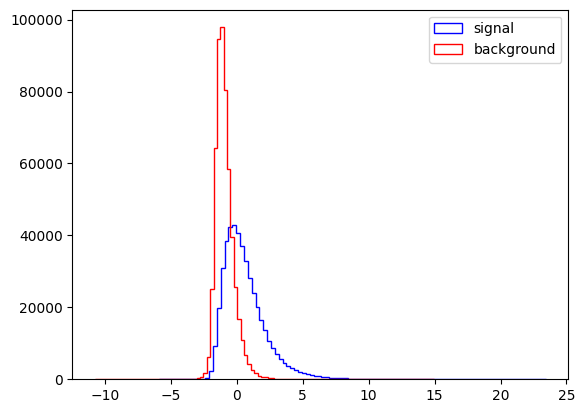

In [6]:
plt.figure()    # Create a new figure for plotting

# Plot histogram of Fisher LDA decision function scores for test signal data
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),  # Compute decision scores for signal
         bins=100,              # Data divided into 100 equal sized bins
         histtype="step",       # step style for histogram
         color="blue",          # make the signal histogram appear blue
         label="signal",        # Label for legend
         stacked=True)          # Stack bars

# Plot histogram of Fisher LDA decision function scores for test background data
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),  # Compute decision scores for background
         bins=100,              # data divided into 100 equal sized bins
         histtype="step",       # Step style for histogram
         color="red",           # make the background samples histogram appear red
         label="background",    # Label for legend
         stacked=True)          # Stack bars

# Display the legend in upper right corner of the plot
plt.legend(loc='upper right')

# display the plot
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

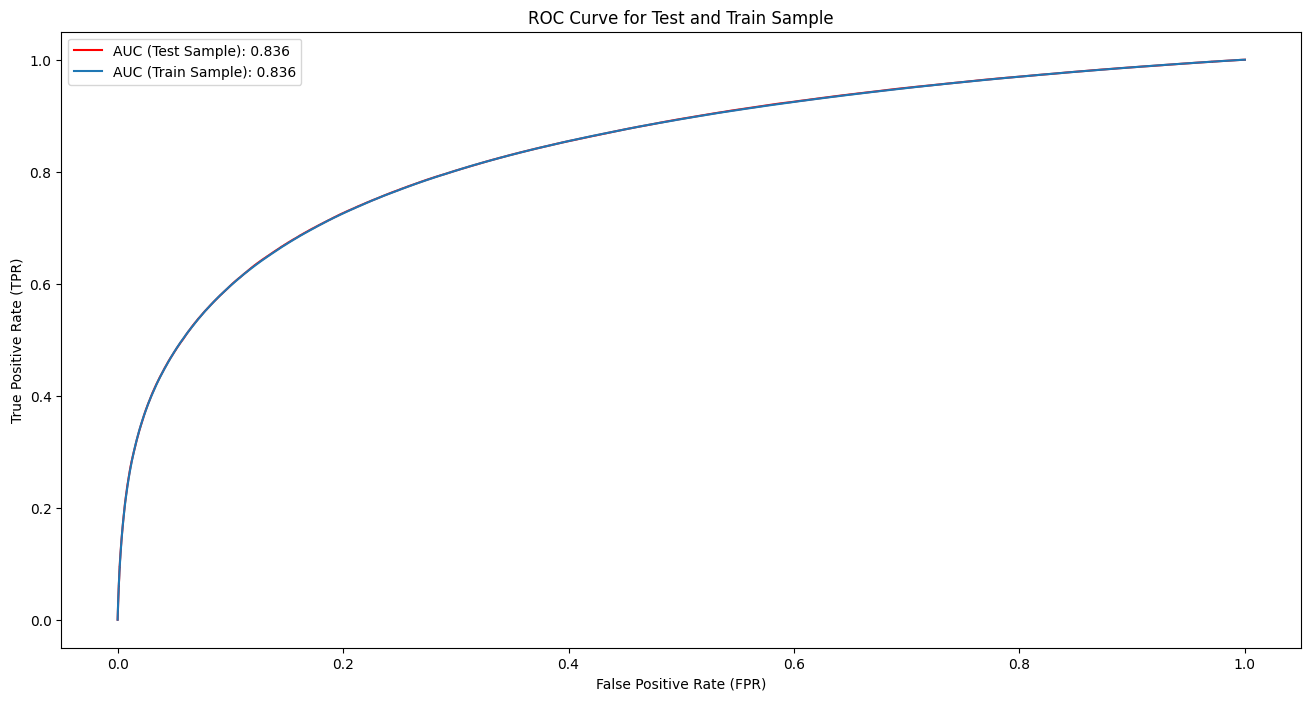

In [7]:
from sklearn.metrics import roc_curve, auc

#ROC on test sample
y_Pred= Fisher.decision_function(X_Test)    #Get the predictions for X_Test samples and store it
fpr_test, tpr_test, _= roc_curve(y_Test, y_Pred)    #Calculate the fpr, tpr, and respective threshold (no variable for threshold as it is not importtant for this problem)
auc_test= auc(fpr_test, tpr_test)   #Calculate the AUC score


#ROC on train sample: Perform similar steps as above, but for the training sample: X_Train
y_Train_pred= Fisher.decision_function(X_Train)
fpr_train, tpr_train, _ = roc_curve(y_Train, y_Train_pred)
auc_train= auc(fpr_train, tpr_train)

#Plotting the 'ROC Curve'
plt.figure(figsize=(16,8))    #Create a canvas grid of size 16 by 8

#Plot fpr against tpr for train and test samples respectively.
plt.plot(fpr_test, tpr_test, color='red', label=f"AUC (Test Sample): {auc_test:.3f}")    #For test sample: red in color
plt.plot(fpr_train, tpr_train, label=f"AUC (Train Sample): {auc_train:.3f}")    #For train sample: blue in color(by default)
plt.legend()    #Display legend (by default displays it in an empty space)
plt.title("ROC Curve for Test and Train Sample")    #Title for the plot

#X and y labels for the plot
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

#Render and display the plot
plt.show()

Since both the training and the testing sets of data have the AUC of 0.836 and the two lines overlap completely, we could say that the model is performing equally on both sets of data. This means that there is no bias.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [8]:
raw_features = VarNames[1:9]  # l_1_pT, l_1_eta, l_1_phi, l_2_pT, l_2_eta, l_2_phi, MET, MET_phi
engineered_features = VarNames[9:]  # MET_rel, axial_MET, M_R, M_TR_2, R, MT2, S_R, M_Delta_R, cos_theta_r1
all_features= raw_features+engineered_features

In [9]:
#Defining a LinearDiscriminantAnalysis() module for different Raw and Engineered features combinations
Fisher_Raw        = DA.LinearDiscriminantAnalysis()    #For Raw features only
Fisher_Engineered = DA.LinearDiscriminantAnalysis()    #For Engineered features only
Fisher_All        = DA.LinearDiscriminantAnalysis()    #For All (Raw and Engineered) features

In [10]:
#For Raw variables
#Since the test and train samples have already been created above, I will be using the same samples over here.
X_Train_raw=Train_Sample[raw_features]    #From the above defined training samples, create a new Training samples with only Raw Features
X_Test_raw=Test_Sample[raw_features]    #From the above defined test samples, create a new test samples with only Raw Features

#Since we are about to use the same test-train split as above, the y_Train and y_Test for the rest of our problems will be same and neddn't to be changed.

In [11]:
Fisher_Raw.fit(X_Train_raw, y_Train)    #Train the classifier model for Raw Features only

LinearDiscriminantAnalysis()

In [12]:
# For engineered features: Perform the same steps as for Raw features, but using the Engineered Features instead.
X_Train_engr=Train_Sample[engineered_features]
X_Test_engr=Test_Sample[engineered_features]

In [13]:
Fisher_Engineered.fit(X_Train_engr, y_Train)    #Train the classifier model for Engineered Features only

LinearDiscriminantAnalysis()

In [14]:
# For all Features: Including all the Engineered and Raw features
X_Train_all=Train_Sample[raw_features + engineered_features]

X_Test_all=Test_Sample[raw_features + engineered_features]

Fisher_All.fit(X_Train_all, y_Train)    #Train for All Features

LinearDiscriminantAnalysis()

For plotting the performance of the model, instead of going one by one for every model, I will be create a `models` dictionary that will hold the information of each models required for the plot and loop over each model. 

In [15]:
# Creatining a dictionary that holds model information. Format: "Model_name": (Model, X_Train_Samples, X_Test_Samples)

models= {
    'Fisher Raw': (Fisher_Raw, X_Train_raw, X_Test_raw),
    'Fisher Engineered': (Fisher_Engineered, X_Train_engr, X_Test_engr),
    'Fisher All': (Fisher_All, X_Train_all, X_Test_all)
}

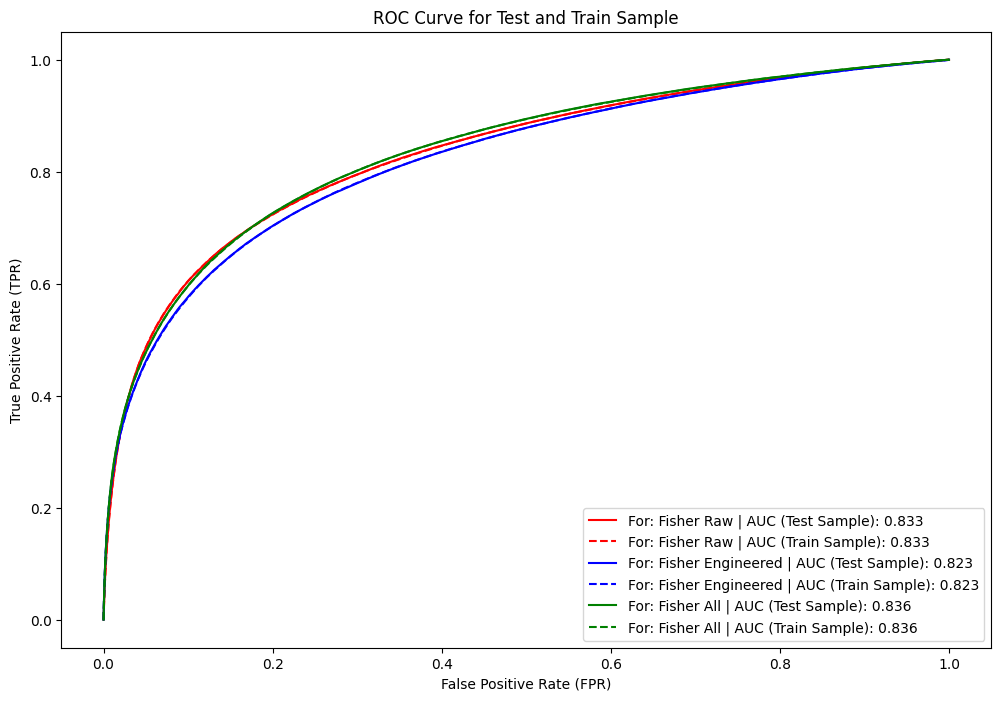

In [16]:
colors=['Red', 'Blue', 'Green']    #Defining 3 different colors for 3 different models
plt.figure(figsize= (12, 8))    #Create a canvas grid of 12 by 8 for plotting


#Zip the model ietms (key, values) with colors and loop through it to get Model_name, Model_Object, X_Train, X_Test, and color.
for (name, (model, x_train, x_test)), color in zip(models.items(), colors):
    
    #ROC on test sample
    y_pred= model.decision_function(x_test)    #Calculate and store the predictions for test samples
    fpr_test, tpr_test, _= roc_curve(y_Test, y_pred)    #returns fpr, tpr, and threshold
    auc_test= auc(fpr_test, tpr_test)    #Returns AUC score


    #ROC on train sample: Perofrm same steps as for test samples.
    y_train_pred= model.decision_function(x_train)
    fpr_train, tpr_train, _ = roc_curve(y_Train, y_train_pred)
    auc_train= auc(fpr_train, tpr_train)
    
    #Plot for Test samples: smooth line with respective index color
    plt.plot(fpr_test, tpr_test, color=color, label=f"For: {name} | AUC (Test Sample): {auc_test:.3f}")
    #Plor for Train sample: dashed line with respective index color
    plt.plot(fpr_train, tpr_train, color=color, linestyle='--', label=f"For: {name} | AUC (Train Sample): {auc_train:.3f}")
plt.legend()    #Show legend
plt.title("ROC Curve for Test and Train Sample")    #Provide the title to plot

#Set x -axis and y-axis labels for the plot
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

#Render and display the plot
plt.show()

This model provide almost same result for all the combinations of raw and engineered features, with a slight better performance when all the features are being used. For all combinations, the result for test and train samples are similar showing no bais in the model.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

**Part a**

Here is the list of algorithms I have choose for comparision.
1. Gaussian Naive Bayes Classifier
1. Logistic Regression 
1. Hist Gradient Boosting Classifier

In [17]:
from sklearn.naive_bayes import GaussianNB     #Import GaussianNB
from sklearn.linear_model import LogisticRegression    #Import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier    #Import HistGradientBoostingClassifier
from sklearn.base import clone

NB_Model     = GaussianNB()    # Naive Bayes Model
LR_Model      = LogisticRegression(max_iter=1000, random_state=42)    # Linear model
Boost_Model  = HistGradientBoostingClassifier(random_state=42)    #GradientBoost Model

In [18]:
#Defining a function to train, test and compare the models under different feature combinations
def ModelEvaluation(model, x_samples):    #Takes model and x_samples(Train, Test) as argument
    colors=['Red', 'Blue', 'Green']    #Colors for different combinations scenarios
    names= ['Raw', "Engineered", "All"]    # List representing selected features name
    plt.figure(figsize= (12, 8))
    
    #Zip x_samples, colors, and names together and loop through each one of them
    for (x_train, x_test), color, name in zip(x_samples, colors, names):
        fresh_model= clone(model)    #Create a fresh copy of the current model
        fresh_model.fit(x_train, y_Train)    #Train the current model
        
        
        #ROC on test sample
        y_prob= fresh_model.predict_proba(x_test)[:, 1]    #Calcluate the probability for test_samples
        fpr_test, tpr_test, _= roc_curve(y_Test, y_prob)    #returns corresponding fpr, tpr, and threshold for the test samples and stored it
        auc_test= auc(fpr_test, tpr_test)    #Calculate the AUC score for test sample


        #ROC on train sample: Perform same things as in above, but for train sample
        y_train_pred= fresh_model.predict_proba(x_train)[:, 1]
        fpr_train, tpr_train, _ = roc_curve(y_Train, y_train_pred)
        auc_train= auc(fpr_train, tpr_train)
    
    
        #Plot for Test Samples: respective indexed color with a smooth line
        plt.plot(fpr_test, tpr_test, color=color, label=f"For: {name} | AUC (Test Sample): {auc_test:.3f}")
        
        #Plot for Train Samples: respective indexed color with dashed line
        plt.plot(fpr_train, tpr_train, color=color, linestyle='--', label=f"For: {name} | AUC (Train Sample): {auc_train:.3f}")

    #Display legend
    plt.legend()
    
    #Provide Title, x-axis label, and y-axis label to the plot respectively
    plt.title(f"ROC Curve for Test and Train Sample | {model}")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    
    #Render and display the plot
    plt.show()

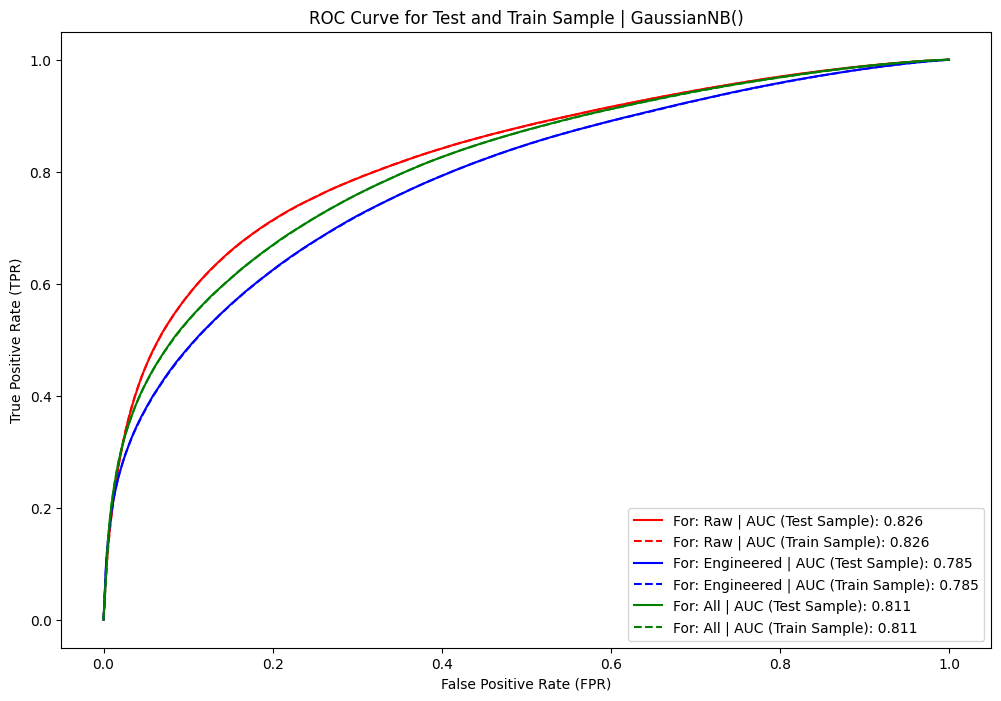

In [19]:
#Define a list of tuple that holds the train and test samples for each feature combination
x_samples = [
    (X_Train_raw,  X_Test_raw),
    (X_Train_engr, X_Test_engr),
    (X_Train_all,  X_Test_all)
]

#Test for Naive Bayes Model (GaussianNB)
ModelEvaluation(NB_Model, x_samples)

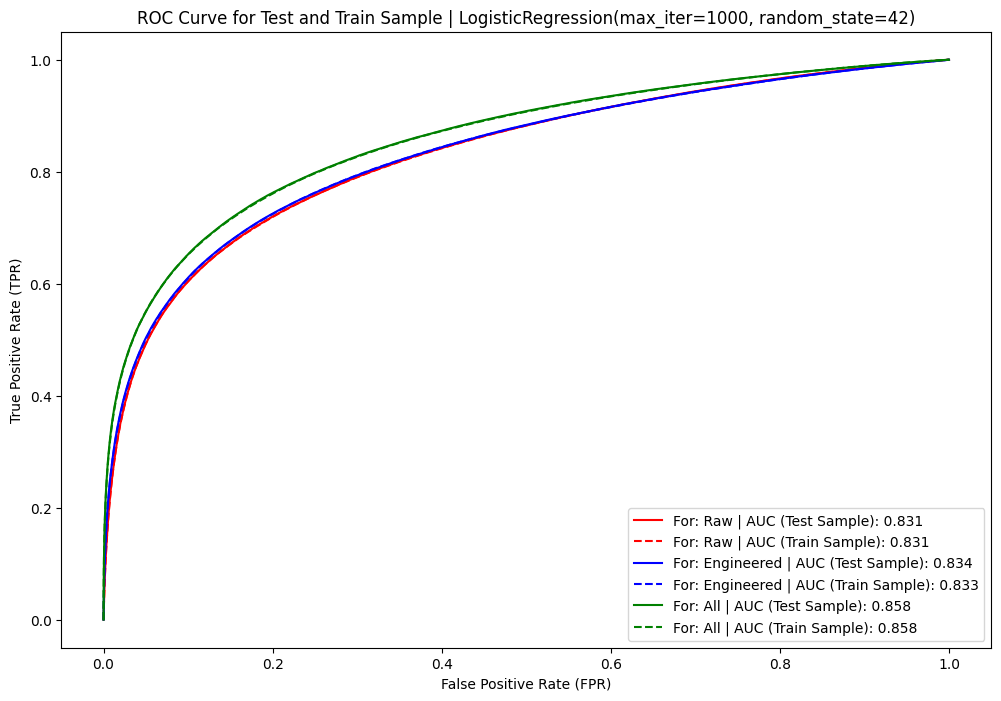

In [20]:
#Test for Linear Model: Logistic Regression
ModelEvaluation(LR_Model, x_samples)

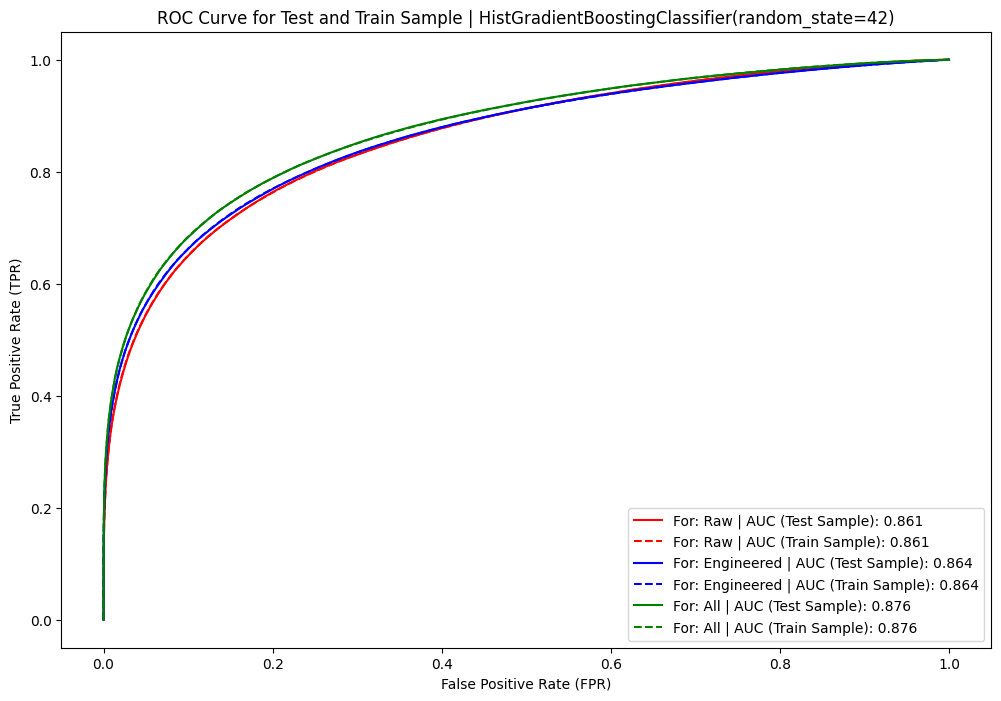

In [21]:
# Test for Gradient Boost Model (HistGradientBoostingClassifier)
ModelEvaluation(Boost_Model, x_samples)

**Best Model Selection**:

Boost model gave the best performance with the AUC hovering near 0.87 for all the combinations of raw and engineered features.

In [22]:
# Exercise 4, Part c

#Different event scenarios. Format: (NS and NB)
scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

#Train the HGBC Model 
Boost_Model.fit(x_train, y_Train)

#Predict probabilities for positive class and store it
y_prob = Boost_Model.predict_proba(X_Test_all)[:, 1]

#defining a range of euqally separated thresholds from 0 to 1
thresholds = np.linspace(0, 1, 200)

print(f"{'Scenario':<30} {'Best Cut':>10} {'Max Sigma':>12}")    #Print Table header

#Loop over every (signal, background) scenario
for (NS, NB) in scenarios:
    significances = []    #Empty list for storing significance value for each threshold
    
    #Try every classification threshold
    for cut in thresholds:
        #Convert probability into binary predictions using current threshold
        y_pred   = (y_prob >= cut)
        
        #True positive rate
        eps_S    = np.sum((y_pred == 1) & (y_Test == 1)) / np.sum(y_Test == 1)  # TPR
        #False positive rate
        eps_B    = np.sum((y_pred == 1) & (y_Test == 0)) / np.sum(y_Test == 0)  # FPR
        
        NS_prime = eps_S * NS    #Calculate NS'
        NB_prime = eps_B * NB    #Calculate NB'
        denominator    = np.sqrt(NS_prime + NB_prime)
        
        #Compute the significance, while avoiding the division by 0
        sigma    = NS_prime / denominator if denominator > 0 else 0
        significances.append(sigma)    #store significance for the threshold
    
    #Convert signifinances from list to Numpy array for easier computation
    significances = np.array(significances)
    
    #Find threshold that maximizes significance
    best_cut  = thresholds[np.argmax(significances)]
    
    # Maximum significance value
    max_sigma = np.max(significances)
    
    #Print results for current scenario
    print(f"NS={NS:<6}, NB={NB:<8}   cut={best_cut:.3f}   sigma={max_sigma:.3f}")

Scenario                         Best Cut    Max Sigma
NS=10    , NB=100        cut=0.834   sigma=1.823
NS=100   , NB=1000       cut=0.834   sigma=5.764
NS=1000  , NB=10000      cut=0.834   sigma=18.228
NS=10000 , NB=100000     cut=0.834   sigma=57.641


We can clearly see that the HGBC model outperforms the Lab 7's Linear Discriminant.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

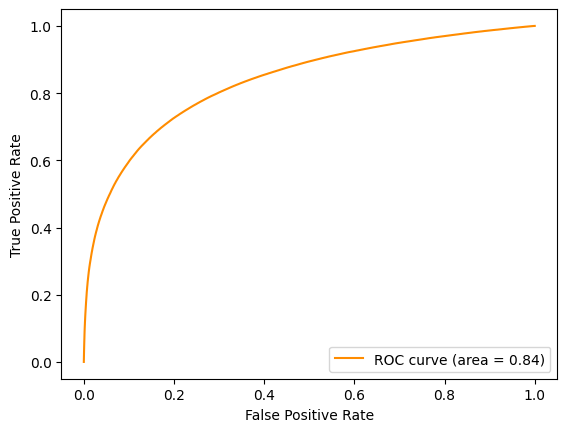

In [23]:
from sklearn.metrics import roc_curve, auc


#Compute false positive, true positive, and threshold
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)    #COmpute the AUC value

#Plot ROC curve
plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


#Render and display the plot
plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [24]:
#Importing the required libraries and modules

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import tabulate
from IPython.display import HTML, display


# Get predicted probabilities for signal class
y_prob = Boost_Model.predict_proba(X_Test_all)[:, 1]

#Compute the TPR, FPR, Threshold, and AUC score 
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_Test, y_prob)
auc_score = auc(fpr_arr, tpr_arr)

#Setting the threshold
best_cut = 0.834

#Convert probabilities into binary predictions using the choosen threshold
y_pred = (y_prob >= best_cut).astype(int)

#True Positive Rate
TPR       = recall_score(y_Test, y_pred)               # sensitivity

#False Positive Rate: Computed from confusion Matrix
FPR       = 1 - (confusion_matrix(y_Test, y_pred)[0,0] / sum(y_Test == 0))

#Standard Classification Metrics
precision = precision_score(y_Test, y_pred)
recall    = TPR    #Recall is same as TPR
f1        = f1_score(y_Test, y_pred)
accuracy  = accuracy_score(y_Test, y_pred)

#Store results for different signals/background scenarios
rows = []
for (NS, NB) in scenarios:
    significances = []    #store sigma values for different cuts
    
    #Loop over possible threshould for finding best signifincances
    for cut in np.linspace(0, 1, 200):
        y_p      = (y_prob >= cut)    #Convert probabilities into binary predictions
        
        eps_S    = np.sum((y_p == 1) & (y_Test == 1)) / np.sum(y_Test == 1)    #TPR
        eps_B    = np.sum((y_p == 1) & (y_Test == 0)) / np.sum(y_Test == 0)    #FPR
        NS_prime = eps_S * NS    #NS'
        NB_prime = eps_B * NB    #NB'
        denominator    = np.sqrt(NS_prime + NB_prime)
        sigma    = NS_prime / denominator if denominator > 0 else 0    #Significance
        significances.append(sigma)
    max_sigma = np.max(significances)    #maximum significance for this scenario
    
    
    #Store result in a row for displaying in the table format
    rows.append([
        f"NS={NS}, NB={NB}",    #Scenario
        f"{TPR:.3f}",    #True Positive Rate
        f"{FPR:.3f}",    #Dalse Positive Rate
        f"{auc_score:.3f}",    #AUC Score
        f"{precision:.3f}",    #Precision 
        f"{recall:.3f}",     #Recall
        f"{f1:.3f}",    #F1
        f"{accuracy:.3f}",    #Accuracy score
        f"{max_sigma:.3f}"    #Maximum significance for scenario
    ])

#Column header for table 
headers = ["Scenario", "TPR", "FPR", "AUC", "Precision", "Recall", "F1", "Accuracy", "Max Significance"]

#Displat result into clean HTML table
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

Scenario,TPR,FPR,AUC,Precision,Recall,F1,Accuracy,Max Significance
"NS=10, NB=100",0.465,0.019,0.876,0.955,0.465,0.625,0.745,1.823
"NS=100, NB=1000",0.465,0.019,0.876,0.955,0.465,0.625,0.745,5.764
"NS=1000, NB=10000",0.465,0.019,0.876,0.955,0.465,0.625,0.745,18.228
"NS=10000, NB=100000",0.465,0.019,0.876,0.955,0.465,0.625,0.745,57.641
